# Challenge 5 — Group 3: Public Health & Epidemiology
## Notebook 02 — Preprocessing & Feature Engineering

**Goal:** Transform the raw BRFSS sample into a clean, scaled feature matrix
ready for K-Means, DBSCAN, and Hierarchical Clustering.

**Pipeline overview:**
1. Imports
2. Load Clean Dataset
3. Feature Selection
4. Missing Value Imputation
5. Feature Encoding
6. Feature Scaling
7. PCA Dimensionality Reduction
8. Save Processed Data



## 1. Imports, Configuration 

In [7]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Pipeline utilities
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Save models
import joblib

# Random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully.")

Libraries loaded successfully.



## 2. Load Sampled Data

In [8]:
# =========================
# Load datasets
# =========================

DATA_PATH_30K = "../data/brfss_sample_30k.csv"
DATA_PATH_5K = "../data/brfss_sample_5k.csv"

df_30k = pd.read_csv(DATA_PATH_30K)
df_5k = pd.read_csv(DATA_PATH_5K)

print("30k dataset shape:", df_30k.shape)
print("5k dataset shape:", df_5k.shape)

30k dataset shape: (29999, 19)
5k dataset shape: (5000, 19)


## Preview dataset

In [9]:


df_30k.head()

,smoking_status,alcohol_any,binge_drinking,physical_activity,bmi,diabetes,coronary_heart_disease,asthma,copd,depression,last_checkup,flu_vaccine,pneumo_vaccine,age_group,sex,education,income_group,race,state
0,1.0,2.0,NaN,1.0,27.12,1.0,1.0,2.0,1.0,2.0,1.0,1.0,1.0,11.0,2.0,4.0,4.0,1.0,50.0
1,4.0,2.0,NaN,1.0,21.93,3.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,10.0,1.0,3.0,4.0,1.0,53.0
2,4.0,2.0,NaN,1.0,19.94,3.0,2.0,2.0,2.0,2.0,1.0,2.0,NaN,1.0,1.0,1.0,7.0,2.0,20.0
3,4.0,1.0,5.0,1.0,30.41,3.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,8.0,1.0,4.0,6.0,1.0,53.0
4,2.0,2.0,NaN,1.0,23.75,3.0,2.0,1.0,2.0,2.0,1.0,2.0,1.0,4.0,1.0,3.0,9.0,2.0,18.0


---
## 3. Define Feature Groups

We separate clustering features from demographic features.
Demographics are carried along but **never fed to the clustering algorithms**.

In [10]:
# =========================
# Dataset information
# =========================

print("30k Dataset Info")
print("=" * 50)

display(df_30k.info())

print("\nMissing values:")
display(df_30k.isnull().sum().sort_values(ascending=False).head(20))

30k Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   smoking_status          29999 non-null  float64
 1   alcohol_any             29048 non-null  float64
 2   binge_drinking          14529 non-null  float64
 3   physical_activity       29911 non-null  float64
 4   bmi                     28177 non-null  float64
 5   diabetes                29938 non-null  float64
 6   coronary_heart_disease  29705 non-null  float64
 7   asthma                  29891 non-null  float64
 8   copd                    29861 non-null  float64
 9   depression              29825 non-null  float64
 10  last_checkup            29661 non-null  float64
 11  flu_vaccine             28988 non-null  float64
 12  pneumo_vaccine          26941 non-null  float64
 13  age_group               29999 non-null  float64
 14  sex                  

None


Missing values:


binge_drinking            15470
pneumo_vaccine             3058
bmi                        1822
flu_vaccine                1011
alcohol_any                 951
last_checkup                338
coronary_heart_disease      294
depression                  174
copd                        138
asthma                      108
physical_activity            88
diabetes                     61
smoking_status                0
age_group                     0
sex                           0
education                     0
income_group                  0
race                          0
state                         0
dtype: int64

In [11]:
# =========================
# Column names
# =========================

print(df_30k.columns.tolist())

['smoking_status', 'alcohol_any', 'binge_drinking', 'physical_activity', 'bmi', 'diabetes', 'coronary_heart_disease', 'asthma', 'copd', 'depression', 'last_checkup', 'flu_vaccine', 'pneumo_vaccine', 'age_group', 'sex', 'education', 'income_group', 'race', 'state']


In [12]:
# =========================
# Feature categorization
# =========================

# Numerical continuous variables
numerical_features = [
    "bmi"
]

# Binary variables
binary_features = [
    "smoking_status",
    "alcohol_any",
    "binge_drinking",
    "physical_activity",
    "diabetes",
    "coronary_heart_disease",
    "asthma",
    "copd",
    "depression",
    "flu_vaccine",
    "pneumo_vaccine",
    "sex"
]

# Categorical / ordinal variables
categorical_features = [
    "last_checkup",
    "age_group",
    "education",
    "income_group",
    "race",    
]

# Combine all selected features
selected_features = (
    numerical_features
    + binary_features
    + categorical_features
)

print("Total selected features:", len(selected_features))
print(selected_features)

Total selected features: 18
['bmi', 'smoking_status', 'alcohol_any', 'binge_drinking', 'physical_activity', 'diabetes', 'coronary_heart_disease', 'asthma', 'copd', 'depression', 'flu_vaccine', 'pneumo_vaccine', 'sex', 'last_checkup', 'age_group', 'education', 'income_group', 'race']


In [13]:
# =========================
# Validate feature existence
# =========================

missing_cols = [col for col in selected_features if col not in df_30k.columns]

if len(missing_cols) == 0:
    print("All selected features exist.")
else:
    print("Missing columns:")
    print(missing_cols)


All selected features exist.


In [14]:
# =========================
# Subset dataset
# =========================

df_selected = df_30k[selected_features].copy()

print("Selected dataset shape:", df_selected.shape)

df_selected.head()

Selected dataset shape: (29999, 18)


,bmi,smoking_status,alcohol_any,binge_drinking,physical_activity,diabetes,coronary_heart_disease,asthma,copd,depression,flu_vaccine,pneumo_vaccine,sex,last_checkup,age_group,education,income_group,race
0,27.12,1.0,2.0,NaN,1.0,1.0,1.0,2.0,1.0,2.0,1.0,1.0,2.0,1.0,11.0,4.0,4.0,1.0
1,21.93,4.0,2.0,NaN,1.0,3.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,10.0,3.0,4.0,1.0
2,19.94,4.0,2.0,NaN,1.0,3.0,2.0,2.0,2.0,2.0,2.0,NaN,1.0,1.0,1.0,1.0,7.0,2.0
3,30.41,4.0,1.0,5.0,1.0,3.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,8.0,4.0,6.0,1.0
4,23.75,2.0,2.0,NaN,1.0,3.0,2.0,1.0,2.0,2.0,2.0,1.0,1.0,1.0,4.0,3.0,9.0,2.0


---
## 4. PRE-Processing Data

We will use simple imputation

In [15]:
# =========================
# Final feature groups
# =========================

numerical_features = [
    "bmi"
]

binary_features = [
    'alcohol_any',
    'binge_drinking',
    'physical_activity',
    'diabetes',
    'coronary_heart_disease',
    'asthma',
    'copd',
    'depression',
    'flu_vaccine',
    'pneumo_vaccine',
    'sex'
]

categorical_features = [
    'smoking_status',
    'last_checkup',
    'age_group',
    'education',
    'income_group',
    'race'
]

selected_features = (
    numerical_features
    + binary_features
    + categorical_features
)

In [16]:
# =========================
# Subset final dataset
# =========================

df_selected = df_30k[selected_features].copy()

print(df_selected.shape)

df_selected.head()

(29999, 18)


,bmi,alcohol_any,binge_drinking,physical_activity,diabetes,coronary_heart_disease,asthma,copd,depression,flu_vaccine,pneumo_vaccine,sex,smoking_status,last_checkup,age_group,education,income_group,race
0,27.12,2.0,NaN,1.0,1.0,1.0,2.0,1.0,2.0,1.0,1.0,2.0,1.0,1.0,11.0,4.0,4.0,1.0
1,21.93,2.0,NaN,1.0,3.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,4.0,1.0,10.0,3.0,4.0,1.0
2,19.94,2.0,NaN,1.0,3.0,2.0,2.0,2.0,2.0,2.0,NaN,1.0,4.0,1.0,1.0,1.0,7.0,2.0
3,30.41,1.0,5.0,1.0,3.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,4.0,1.0,8.0,4.0,6.0,1.0
4,23.75,2.0,NaN,1.0,3.0,2.0,1.0,2.0,2.0,2.0,1.0,1.0,2.0,1.0,4.0,3.0,9.0,2.0


In [17]:
# =========================
# Missing values check
# =========================

missing_summary = (
    df_selected
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

display(missing_summary)

binge_drinking            15470
pneumo_vaccine             3058
bmi                        1822
flu_vaccine                1011
alcohol_any                 951
last_checkup                338
coronary_heart_disease      294
depression                  174
copd                        138
asthma                      108
physical_activity            88
diabetes                     61
sex                           0
smoking_status                0
age_group                     0
education                     0
income_group                  0
race                          0
dtype: int64

In [18]:
# =========================
# Preprocessing Pipelines
# =========================

# Numerical pipeline
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Binary pipeline
binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [19]:
# =========================
# Column transformer
# =========================

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("bin", binary_pipeline, binary_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [20]:
# =========================
# Fit and transform
# =========================

X_processed = preprocessor.fit_transform(df_selected)

print("Processed matrix shape:", X_processed.shape)

Processed matrix shape: (29999, 51)


In [21]:
# Convert sparse matrix to dense if needed

if hasattr(X_processed, "toarray"):
    X_processed = X_processed.toarray()

print(type(X_processed))
print(X_processed.shape)

<class 'numpy.ndarray'>
(29999, 51)


---
## 5. PCA

Features with >40% missing values provide more noise than signal.
We drop them from both samples.

In [22]:
from sklearn.decomposition import PCA

RANDOM_STATE = 42

In [23]:
# =========================
# PCA - Explained Variance
# =========================

pca_full = PCA(random_state=RANDOM_STATE)

pca_full.fit(X_processed)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Total PCA components:", len(explained_variance))

Total PCA components: 51


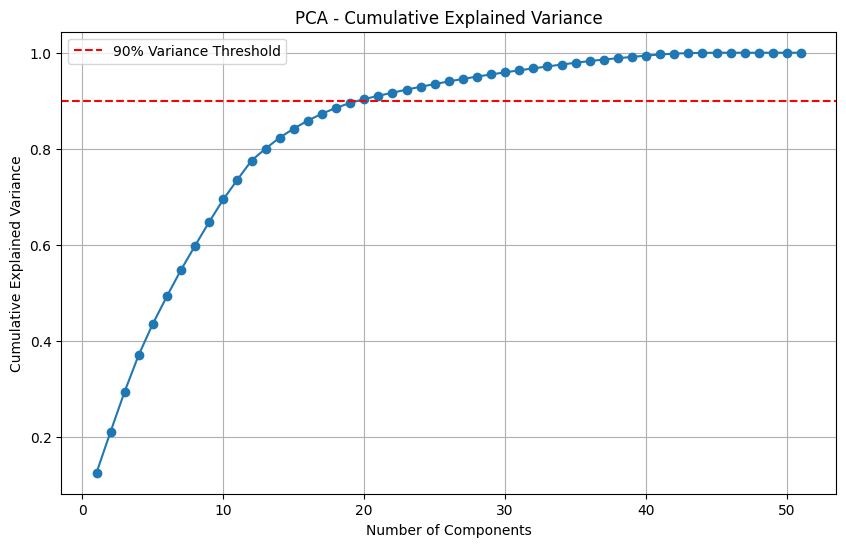

In [32]:
# =========================
# Cumulative Variance Plot
# =========================

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)

plt.axhline(
    y=0.90,
    color='red',
    linestyle='--',
    label='90% Variance Threshold'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance")
plt.legend()

plt.grid(True)
plt.savefig('/home/sbuitrago/challenge5__3/figures/cumulative_variance.png', dpi=300, bbox_inches='tight')

plt.show()

In [26]:
# =========================
# Optimal number of components
# =========================

n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print(f"Number of components for 90% variance: {n_components_90}")

Number of components for 90% variance: 20


# Final PCA transformation

In [27]:
pca = PCA(
    n_components=n_components_90,
    random_state=RANDOM_STATE
)

X_pca = pca.fit_transform(X_processed)

print("Original shape:", X_processed.shape)
print("PCA shape:", X_pca.shape)

Original shape: (29999, 51)
PCA shape: (29999, 20)


# Explained variance summary

In [28]:

total_variance = np.sum(pca.explained_variance_ratio_)

print(f"Total retained variance: {total_variance:.4f}")

Total retained variance: 0.9036


# First 2 PCA components visualization

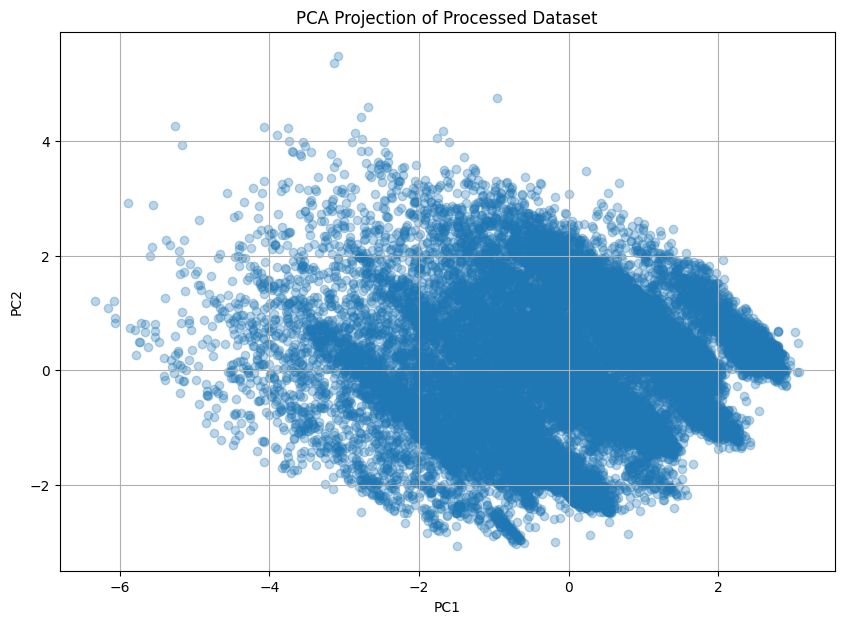

In [31]:

plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.3
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of Processed Dataset")

plt.grid(True)
plt.savefig('/home/sbuitrago/challenge5__3/figures/pca_projection.png', dpi=300, bbox_inches='tight')

plt.show()

# Save preprocessing artifacts

In [30]:


os.makedirs("../results", exist_ok=True)

# Save datasets
np.save("../results/X_processed.npy", X_processed)
np.save("../results/X_pca.npy", X_pca)

# Save models
joblib.dump(preprocessor, "../results/preprocessor.pkl")
joblib.dump(pca, "../results/pca_model.pkl")

print("Preprocessing artifacts saved successfully.")

Preprocessing artifacts saved successfully.
